In [1]:
import random
import gymnasium as gym
from collections import namedtuple, deque
from itertools import count
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from torch.utils.tensorboard import SummaryWriter
from dqn import DQN

# Initialize TensorBoard writer
writer = SummaryWriter()

num_episodes = 600
batch_size = 128
GAMMA = 0.99
LR = 1e-4
TAU = 0.005

EPSILON = 1.0
EPSILON_MIN = 0.01
EPSILON_DECAY = 0.995

reward_list = []
episode_durations = []

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

Transition = namedtuple(
    "Transition", ["state", "action", "next_state", "reward", "done"]
)


class ReplayMemory:
    def __init__(self, capacity):
        self.memory = deque([], maxlen=capacity)

    def push(self, *args):
        self.memory.append(Transition(*args))

    def sample(self, batch_size):
        return (
            random.sample(self.memory, batch_size)
            if batch_size < len(self.memory)
            else self.memory
        )

    def __len__(self):
        return len(self.memory)


# Initialize the environment
env = gym.make("LunarLander-v3")

n_observations = env.observation_space.shape[0]

# ============================================================
# MODIFIED: Only use actions [1, 2, 3], remove action 0 (NOOP)
# ============================================================
# Action mapping:
#   Original LunarLander: 0=Nothing, 1=Left, 2=Main, 3=Right
#   We use: [1, 2, 3] = [Left, Main, Right]
#   DQN output index 0 -> action 1 (Left)
#   DQN output index 1 -> action 2 (Main)
#   DQN output index 2 -> action 3 (Right)

AVAILABLE_ACTIONS = [1, 2, 3]  # Actions we can use
n_actions = len(AVAILABLE_ACTIONS)  # 3 actions

print(f"Using {n_actions} actions: {AVAILABLE_ACTIONS}")
print(f"Removed action 0 (NOOP/Nothing)")

policy_net = DQN(n_observations, n_actions).to(device)
target_net = DQN(n_observations, n_actions).to(device)
target_net.load_state_dict(policy_net.state_dict())

replay_memory = ReplayMemory(10000)


def select_action(state):
    """Select action from AVAILABLE_ACTIONS only."""
    if np.random.rand() < EPSILON:
        # Random action from available actions
        action_idx = random.randint(0, n_actions - 1)
        return torch.tensor([[action_idx]], dtype=torch.long, device=device)
    else:
        with torch.no_grad():
            # Get best action index from DQN (0, 1, or 2)
            return policy_net(state).max(1).indices.view(1, 1)


def action_idx_to_env_action(action_idx):
    """Convert DQN output index to actual environment action.
    
    DQN index 0 -> env action 1 (Left)
    DQN index 1 -> env action 2 (Main)
    DQN index 2 -> env action 3 (Right)
    """
    return AVAILABLE_ACTIONS[action_idx]


optimizer = optim.AdamW(policy_net.parameters(), lr=LR)
criterion = nn.SmoothL1Loss()

for episode in range(num_episodes):
    state, info = env.reset()
    state = torch.tensor(state, dtype=torch.float32, device=device).unsqueeze(0)
    total_reward = 0

    for t in count():
        # Select action index (0, 1, or 2)
        action_idx = select_action(state)
        
        # Convert to environment action (1, 2, or 3)
        env_action = action_idx_to_env_action(action_idx.item())
        
        # Step environment with actual action
        next_state, reward, terminated, truncated, info = env.step(env_action)

        done = terminated or truncated
        reward = torch.tensor([reward], device=device)
        next_state = torch.tensor(
            next_state, dtype=torch.float32, device=device
        ).unsqueeze(0)
        
        # Store action INDEX (not env action) in replay memory
        replay_memory.push(state, action_idx, next_state, reward, done)

        state = next_state
        total_reward += reward.item()

        if len(replay_memory) >= batch_size:
            transitions = replay_memory.sample(batch_size)
            states, actions, next_states, rewards, dones = zip(*transitions)

            states_batch = torch.cat(states)
            next_states_batch = torch.cat(next_states)
            actions_batch = torch.cat(actions)
            rewards = torch.tensor(rewards, device=device)
            dones = torch.tensor(dones, dtype=torch.float32, device=device)

            # Get Q-values for taken actions
            q_values = policy_net(states_batch).gather(1, actions_batch).squeeze()

            # Compute target Q-values
            with torch.no_grad():
                next_q_values = target_net(next_states_batch).max(1).values
                target_q_values = rewards + GAMMA * next_q_values * (1 - dones)

            loss = criterion(q_values, target_q_values)

            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(policy_net.parameters(), 1.0)
            optimizer.step()

            # Soft update target network
            for target_param, policy_param in zip(target_net.parameters(), policy_net.parameters()):
                target_param.data.copy_(TAU * policy_param.data + (1 - TAU) * target_param.data)

        if done:
            episode_durations.append(t + 1)
            break

    # Decay epsilon
    EPSILON = max(EPSILON_MIN, EPSILON * EPSILON_DECAY)

    reward_list.append(total_reward)

    # Log to TensorBoard
    writer.add_scalar("Reward/Episode", total_reward, episode)
    writer.add_scalar("Epsilon", EPSILON, episode)

    if (episode + 1) % 10 == 0:
        avg_reward = np.mean(reward_list[-10:])
        print(f"Episode {episode+1}/{num_episodes}, Reward: {total_reward:.2f}, "
              f"Avg10: {avg_reward:.2f}, Epsilon: {EPSILON:.3f}")

# Save the trained model
torch.save(policy_net.state_dict(), "policy_net_3actions.pth")
print("\nModel saved to policy_net_3actions.pth")
print(f"Trained with actions: {AVAILABLE_ACTIONS}")

writer.close()
env.close()

/opt/anaconda3/envs/rl_env/lib/python3.10/site-packages/google/protobuf/runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.0 at tensorflow/core/framework/attr_value.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
/opt/anaconda3/envs/rl_env/lib/python3.10/site-packages/google/protobuf/runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.0 at tensorflow/core/framework/tensor.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
/opt/anaconda3/envs/rl_env/lib/python3.10/site-packages/google/protobuf/runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.0 at tensorflow/core/framework/resource_handle.proto. Please update the gencode

cpu
Using 3 actions: [1, 2, 3]
Removed action 0 (NOOP/Nothing)
Episode 10/600, Reward: -50.08, Avg10: -150.09, Epsilon: 0.951
Episode 20/600, Reward: -395.40, Avg10: -250.07, Epsilon: 0.905
Episode 30/600, Reward: -420.51, Avg10: -226.40, Epsilon: 0.860
Episode 40/600, Reward: -95.33, Avg10: -117.96, Epsilon: 0.818
Episode 50/600, Reward: 9.75, Avg10: -86.03, Epsilon: 0.778
Episode 60/600, Reward: -75.25, Avg10: -75.07, Epsilon: 0.740
Episode 70/600, Reward: -75.24, Avg10: -97.59, Epsilon: 0.704
Episode 80/600, Reward: -57.40, Avg10: -60.39, Epsilon: 0.670
Episode 90/600, Reward: -30.81, Avg10: -72.71, Epsilon: 0.637
Episode 100/600, Reward: 30.00, Avg10: -41.38, Epsilon: 0.606
Episode 110/600, Reward: -36.60, Avg10: -41.40, Epsilon: 0.576
Episode 120/600, Reward: -253.01, Avg10: -52.66, Epsilon: 0.548
Episode 130/600, Reward: -23.98, Avg10: -42.91, Epsilon: 0.521
Episode 140/600, Reward: -52.25, Avg10: -96.80, Epsilon: 0.496
Episode 150/600, Reward: -17.33, Avg10: -12.39, Epsilon: 0.4

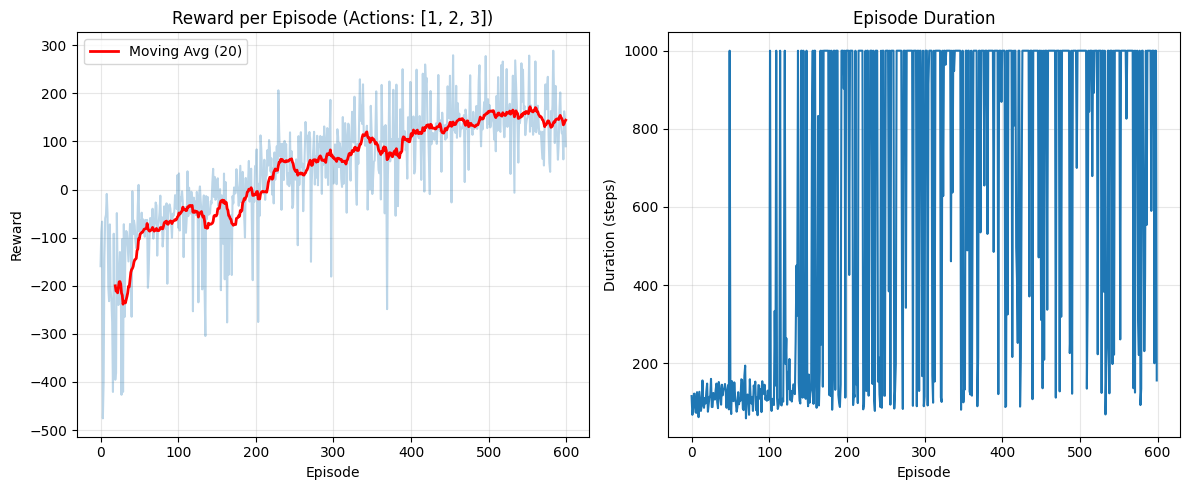


Final Stats (last 50 episodes):
  Average Reward: 142.83
  Max Reward: 288.74
  Min Reward: 36.93


In [2]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

# Plot rewards
plt.subplot(1, 2, 1)
plt.plot(reward_list, alpha=0.3)
# Moving average
window = 20
if len(reward_list) >= window:
    moving_avg = np.convolve(reward_list, np.ones(window)/window, mode='valid')
    plt.plot(range(window-1, len(reward_list)), moving_avg, color='red', lw=2, label=f'Moving Avg ({window})')
plt.xlabel('Episode')
plt.ylabel('Reward')
plt.title(f'Reward per Episode (Actions: {AVAILABLE_ACTIONS})')
plt.legend()
plt.grid(alpha=0.3)

# Plot episode durations
plt.subplot(1, 2, 2)
plt.plot(episode_durations)
plt.xlabel('Episode')
plt.ylabel('Duration (steps)')
plt.title('Episode Duration')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('training_3actions.png', dpi=150)
plt.show()

print(f"\nFinal Stats (last 50 episodes):")
print(f"  Average Reward: {np.mean(reward_list[-50:]):.2f}")
print(f"  Max Reward: {max(reward_list[-50:]):.2f}")
print(f"  Min Reward: {min(reward_list[-50:]):.2f}")

TRANSITION MODEL FOR ACTION 0 (NOOP)
With Early Stopping and Regularization
Using device: cpu

--- Regularization Settings ---
Dropout: 0.2
Weight Decay: 0.0001
Early Stopping Patience: 20

Collected 4867 transitions for action 0
Training samples: 3893
Testing samples: 974

Training for up to 100 epochs (early stopping enabled)...
Epoch  10/100 | Train Loss: -1.8158 | Test Loss: -2.0367 | Train MSE: 0.040274 | Test MSE: 0.047206 | No improvement: 4
Epoch  20/100 | Train Loss: -1.9039 | Test Loss: -2.1450 | Train MSE: 0.039762 | Test MSE: 0.046967 | No improvement: 6
Epoch  30/100 | Train Loss: -1.8700 | Test Loss: -2.1872 | Train MSE: 0.041309 | Test MSE: 0.046801 | No improvement: 16

*** Early stopping at epoch 34 (no improvement for 20 epochs) ***

Loaded best model from epoch 14 (Test MSE: 0.046292)
Model saved to transition_model_action0.pth


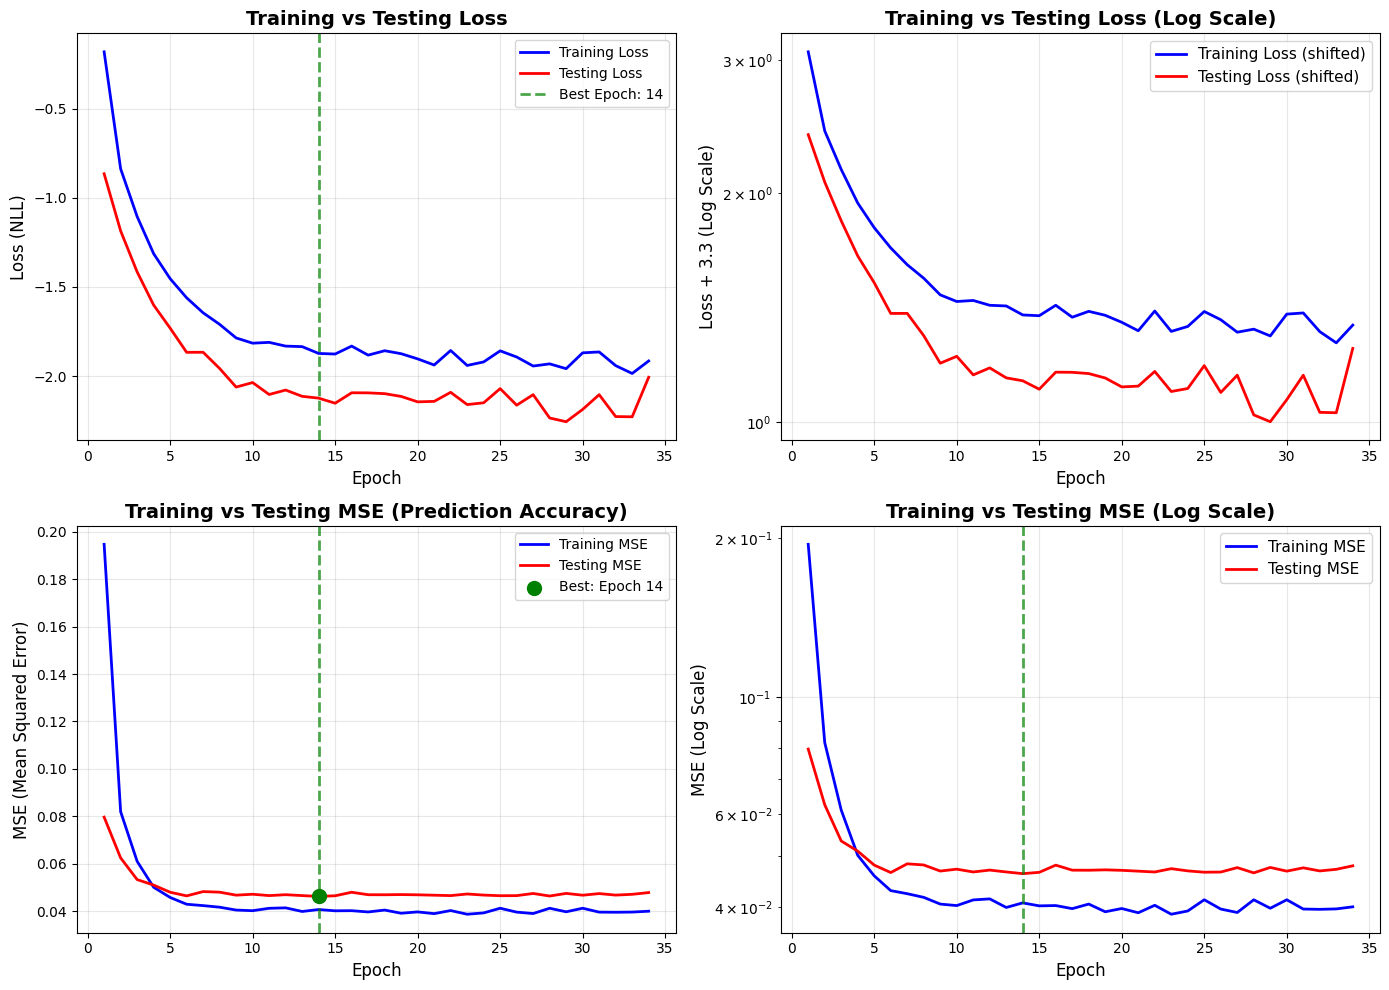


OVERFITTING CHECK SUMMARY

--- Loss (NLL) ---
Final Training Loss: -1.915524
Final Testing Loss:  -2.007102

--- MSE (Prediction Accuracy) ---
Final Training MSE:  0.040057
Final Testing MSE:   0.047902
Best Testing MSE:    0.046292 (Epoch 14)
Final RMSE:          0.218866

--- Early Stopping ---
Best model saved at: Epoch 14

--- Overfitting Analysis ---
MSE Gap (Test - Train): 0.007845

✅ Model generalizes well!

Results saved to 'transition_model_overfitting.png'


In [3]:
"""
Transition Model for Action 0 (NOOP/Nothing)
=============================================

This MLP predicts: s' = f(s, a=0)
Given current state s, predict next state s' when taking action 0 (do nothing).

The model learns from real transitions collected when action 0 is executed.
"""

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from collections import deque
import gymnasium as gym


class TransitionModelAction0(nn.Module):
    """
    MLP to predict next state for action 0 (NOOP).
    
    Input: state s (8-dim for LunarLander)
    Output: predicted next state s' (8-dim)
    
    Optionally outputs variance for uncertainty estimation.
    """
    
    def __init__(self, state_dim=8, hidden_dim=128, with_variance=True, dropout=0.2):
        super().__init__()
        
        self.state_dim = state_dim
        self.with_variance = with_variance
        
        # Shared layers with dropout for regularization
        self.fc1 = nn.Linear(state_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.fc3 = nn.Linear(hidden_dim, hidden_dim)
        
        # Dropout for regularization
        self.dropout = nn.Dropout(dropout)
        
        # Mean prediction (next state)
        self.fc_mean = nn.Linear(hidden_dim, state_dim)
        
        # Variance prediction (for uncertainty/confidence)
        if with_variance:
            self.fc_logvar = nn.Linear(hidden_dim, state_dim)
        
        self.relu = nn.ReLU()
        
    def forward(self, state):
        """
        Forward pass.
        
        Args:
            state: [batch, state_dim] or [state_dim]
            
        Returns:
            mean: predicted next state
            logvar: log variance (if with_variance=True)
        """
        if state.dim() == 1:
            state = state.unsqueeze(0)
            
        h = self.relu(self.fc1(state))
        h = self.dropout(h)
        h = self.relu(self.fc2(h))
        h = self.dropout(h)
        h = self.relu(self.fc3(h))
        h = self.dropout(h)
        
        mean = self.fc_mean(h)
        
        if self.with_variance:
            logvar = self.fc_logvar(h)
            return mean, logvar
        else:
            return mean
    
    def predict(self, state):
        """
        Predict next state with confidence.
        
        Returns:
            next_state: predicted next state
            confidence: confidence score (0 to 1, higher = more confident)
        """
        self.eval()
        with torch.no_grad():
            if isinstance(state, np.ndarray):
                state = torch.FloatTensor(state)
            if state.dim() == 1:
                state = state.unsqueeze(0)
            
            if self.with_variance:
                mean, logvar = self(state)
                # Confidence = exp(-mean_variance)
                variance = torch.exp(logvar)
                confidence = torch.exp(-variance.mean(dim=1))
                return mean.squeeze(0).numpy(), confidence.item()
            else:
                mean = self(state)
                return mean.squeeze(0).numpy(), 1.0


class TransitionDataCollector:
    """
    Collects (state, next_state) pairs for action 0.
    """
    
    def __init__(self, buffer_size=50000):
        self.buffer = deque(maxlen=buffer_size)
        
    def add(self, state, next_state):
        """Add a transition for action 0."""
        self.buffer.append((
            np.array(state).flatten(),
            np.array(next_state).flatten()
        ))
    
    def sample(self, batch_size):
        """Sample a batch of transitions."""
        if batch_size > len(self.buffer):
            batch_size = len(self.buffer)
        indices = np.random.choice(len(self.buffer), batch_size, replace=False)
        states = np.array([self.buffer[i][0] for i in indices])
        next_states = np.array([self.buffer[i][1] for i in indices])
        return states, next_states
    
    def __len__(self):
        return len(self.buffer)


class TransitionModelTrainer:
    """
    Trainer for the transition model.
    """
    
    def __init__(self, model, lr=1e-3, device='cpu'):
        self.model = model.to(device)
        self.device = device
        self.optimizer = optim.Adam(model.parameters(), lr=lr)
        self.data_collector = TransitionDataCollector()
        
    def add_transition(self, state, next_state):
        """Add observed transition for action 0."""
        self.data_collector.add(state, next_state)
        
    def train_step(self, batch_size=64):
        """Perform one training step."""
        if len(self.data_collector) < batch_size:
            return None
        
        states, next_states = self.data_collector.sample(batch_size)
        
        states = torch.FloatTensor(states).to(self.device)
        next_states = torch.FloatTensor(next_states).to(self.device)
        
        self.model.train()
        
        if self.model.with_variance:
            # Negative log-likelihood loss with learned variance
            mean, logvar = self.model(states)
            # NLL = 0.5 * (log(var) + (target - mean)^2 / var)
            loss = 0.5 * (logvar + (next_states - mean)**2 * torch.exp(-logvar)).mean()
        else:
            # Simple MSE loss
            mean = self.model(states)
            loss = nn.MSELoss()(mean, next_states)
        
        self.optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(self.model.parameters(), 1.0)
        self.optimizer.step()
        
        return loss.item()
    
    def train_epochs(self, epochs=10, batch_size=64):
        """Train for multiple epochs."""
        if len(self.data_collector) < batch_size:
            return []
        
        losses = []
        for _ in range(epochs):
            loss = self.train_step(batch_size)
            if loss is not None:
                losses.append(loss)
        return losses
    
    def can_predict(self, min_samples=100):
        """Check if model has enough data to make predictions."""
        return len(self.data_collector) >= min_samples
    
    def save(self, path):
        """Save model weights."""
        torch.save(self.model.state_dict(), path)
        
    def load(self, path):
        """Load model weights."""
        self.model.load_state_dict(torch.load(path))


def collect_action0_data(num_episodes=100, save_path=None):
    """
    Collect transition data for action 0 by running random policy.
    
    Returns:
        data_collector: TransitionDataCollector with collected data
    """
    env = gym.make("LunarLander-v3")
    collector = TransitionDataCollector()
    
    total_action0_transitions = 0
    
    for ep in range(num_episodes):
        state, _ = env.reset()
        done = False
        
        while not done:
            # Random action
            action = env.action_space.sample()
            next_state, reward, term, trunc, _ = env.step(action)
            done = term or trunc
            
            # Only collect if action was 0
            if action == 0:
                collector.add(state, next_state)
                total_action0_transitions += 1
            
            state = next_state
    
    env.close()
    
    print(f"Collected {total_action0_transitions} transitions for action 0")
    print(f"From {num_episodes} episodes")
    
    if save_path:
        import pickle
        with open(save_path, 'wb') as f:
            pickle.dump(list(collector.buffer), f)
        print(f"Saved to {save_path}")
    
    return collector


def train_transition_model(data_collector=None, epochs=100, batch_size=128, 
                           collect_episodes=200, save_path="transition_model_action0.pth"):
    """
    Train the transition model for action 0.
    
    Args:
        data_collector: Pre-collected data, or None to collect new data
        epochs: Number of training epochs
        batch_size: Batch size for training
        collect_episodes: Episodes to collect if data_collector is None
        save_path: Path to save trained model
        
    Returns:
        trainer: Trained TransitionModelTrainer
    """
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")
    
    # Create model
    model = TransitionModelAction0(state_dim=8, hidden_dim=128, with_variance=True)
    trainer = TransitionModelTrainer(model, lr=1e-3, device=device)
    
    # Collect data if not provided
    if data_collector is None:
        print(f"\nCollecting data from {collect_episodes} episodes...")
        data_collector = collect_action0_data(num_episodes=collect_episodes)
    
    # Transfer data to trainer
    trainer.data_collector = data_collector
    
    print(f"\nTraining on {len(data_collector)} transitions...")
    print(f"Epochs: {epochs}, Batch size: {batch_size}")
    
    # Training loop
    all_losses = []
    for epoch in range(epochs):
        losses = trainer.train_epochs(epochs=10, batch_size=batch_size)
        avg_loss = np.mean(losses) if losses else 0
        all_losses.append(avg_loss)
        
        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.6f}")
    
    # Save model
    trainer.save(save_path)
    print(f"\nModel saved to {save_path}")
    
    # Test prediction
    print("\n--- Testing Predictions ---")
    env = gym.make("LunarLander-v3")
    test_errors = []
    
    for _ in range(10):
        state, _ = env.reset()
        # Take action 0
        next_state_true, _, _, _, _ = env.step(0)
        
        # Predict
        next_state_pred, confidence = trainer.model.predict(state)
        
        # Error
        error = np.mean((next_state_true - next_state_pred)**2)
        test_errors.append(error)
        
    env.close()
    
    print(f"Average prediction MSE: {np.mean(test_errors):.6f}")
    print(f"Std prediction MSE: {np.std(test_errors):.6f}")
    
    return trainer, all_losses


# =============================================================================
# Example usage and testing
# =============================================================================

def train_with_validation(collect_episodes=200, epochs=100, batch_size=128, 
                          val_split=0.2, save_path="transition_model_action0.pth",
                          patience=20, weight_decay=1e-4, dropout=0.2):
    """
    Train transition model with train/test split to check overfitting.
    
    Args:
        collect_episodes: Number of episodes to collect data from
        epochs: Maximum number of training epochs
        batch_size: Batch size for training
        val_split: Fraction of data for validation
        save_path: Path to save best model
        patience: Early stopping patience (stop if no improvement for N epochs)
        weight_decay: L2 regularization strength
        dropout: Dropout rate for regularization
    
    Returns:
        trainer: Trained model (best checkpoint)
        train_losses: Training loss per epoch
        test_losses: Testing loss per epoch
        train_mse: Training MSE (accuracy) per epoch
        test_mse: Testing MSE (accuracy) per epoch
    """
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")
    print(f"\n--- Regularization Settings ---")
    print(f"Dropout: {dropout}")
    print(f"Weight Decay: {weight_decay}")
    print(f"Early Stopping Patience: {patience}")
    
    # Collect data
    print(f"\nCollecting data from {collect_episodes} episodes...")
    env = gym.make("LunarLander-v3")
    
    all_transitions = []
    for ep in range(collect_episodes):
        state, _ = env.reset()
        done = False
        while not done:
            action = env.action_space.sample()
            next_state, _, term, trunc, _ = env.step(action)
            done = term or trunc
            if action == 0:
                all_transitions.append((state.copy(), next_state.copy()))
            state = next_state
    env.close()
    
    print(f"Collected {len(all_transitions)} transitions for action 0")
    
    # Shuffle and split data
    np.random.shuffle(all_transitions)
    split_idx = int(len(all_transitions) * (1 - val_split))
    train_data = all_transitions[:split_idx]
    test_data = all_transitions[split_idx:]
    
    print(f"Training samples: {len(train_data)}")
    print(f"Testing samples: {len(test_data)}")
    
    # Prepare tensors
    train_states = torch.FloatTensor(np.array([t[0] for t in train_data])).to(device)
    train_next = torch.FloatTensor(np.array([t[1] for t in train_data])).to(device)
    test_states = torch.FloatTensor(np.array([t[0] for t in test_data])).to(device)
    test_next = torch.FloatTensor(np.array([t[1] for t in test_data])).to(device)
    
    # Create model with dropout
    model = TransitionModelAction0(state_dim=8, hidden_dim=128, with_variance=True, dropout=dropout).to(device)
    
    # Optimizer with weight decay (L2 regularization)
    optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=weight_decay)
    
    train_losses = []
    test_losses = []
    train_mse = []
    test_mse = []
    
    # Early stopping variables
    best_test_mse = float('inf')
    best_epoch = 0
    best_model_state = None
    epochs_without_improvement = 0
    
    print(f"\nTraining for up to {epochs} epochs (early stopping enabled)...")
    
    for epoch in range(epochs):
        # ============ Training ============
        model.train()
        
        # Shuffle training data
        perm = torch.randperm(len(train_states))
        epoch_train_loss = 0
        epoch_train_mse = 0
        n_batches = 0
        
        for i in range(0, len(train_states), batch_size):
            idx = perm[i:i+batch_size]
            batch_s = train_states[idx]
            batch_ns = train_next[idx]
            
            mean, logvar = model(batch_s)
            loss = 0.5 * (logvar + (batch_ns - mean)**2 * torch.exp(-logvar)).mean()
            
            # Calculate MSE (prediction accuracy)
            mse = ((batch_ns - mean)**2).mean()
            
            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            
            epoch_train_loss += loss.item()
            epoch_train_mse += mse.item()
            n_batches += 1
        
        avg_train_loss = epoch_train_loss / n_batches
        avg_train_mse = epoch_train_mse / n_batches
        train_losses.append(avg_train_loss)
        train_mse.append(avg_train_mse)
        
        # ============ Testing ============
        model.eval()
        with torch.no_grad():
            mean, logvar = model(test_states)
            test_loss = 0.5 * (logvar + (test_next - mean)**2 * torch.exp(-logvar)).mean()
            test_mse_val = ((test_next - mean)**2).mean()
            test_losses.append(test_loss.item())
            test_mse.append(test_mse_val.item())
        
        # ============ Early Stopping Check ============
        if test_mse_val.item() < best_test_mse:
            best_test_mse = test_mse_val.item()
            best_epoch = epoch + 1
            best_model_state = model.state_dict().copy()
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1
        
        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1:3d}/{epochs} | Train Loss: {avg_train_loss:.4f} | Test Loss: {test_loss.item():.4f} | "
                  f"Train MSE: {avg_train_mse:.6f} | Test MSE: {test_mse_val.item():.6f} | "
                  f"No improvement: {epochs_without_improvement}")
        
        # Early stopping
        if epochs_without_improvement >= patience:
            print(f"\n*** Early stopping at epoch {epoch+1} (no improvement for {patience} epochs) ***")
            break
    
    # Load best model
    if best_model_state is not None:
        model.load_state_dict(best_model_state)
        print(f"\nLoaded best model from epoch {best_epoch} (Test MSE: {best_test_mse:.6f})")
    
    # Save best model
    torch.save(model.state_dict(), save_path)
    print(f"Model saved to {save_path}")
    
    # Create trainer object for compatibility
    trainer = TransitionModelTrainer(model, device=device)
    
    return trainer, train_losses, test_losses, train_mse, test_mse, best_epoch


def plot_overfitting_check(train_losses, test_losses, train_mse, test_mse, best_epoch=None, save_path='transition_model_overfitting.png'):
    """
    Plot training vs testing loss and MSE to check for overfitting.
    """
    import matplotlib.pyplot as plt
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    epochs = range(1, len(train_losses) + 1)
    
    # ============ Plot 1: Loss Curves (Normal Scale) ============
    ax1 = axes[0, 0]
    ax1.plot(epochs, train_losses, 'b-', linewidth=2, label='Training Loss')
    ax1.plot(epochs, test_losses, 'r-', linewidth=2, label='Testing Loss')
    ax1.set_xlabel('Epoch', fontsize=12)
    ax1.set_ylabel('Loss (NLL)', fontsize=12)
    ax1.set_title('Training vs Testing Loss', fontsize=14, fontweight='bold')
    ax1.legend(fontsize=11)
    ax1.grid(alpha=0.3)
    
    # Mark best epoch
    if best_epoch:
        ax1.axvline(best_epoch, color='green', linestyle='--', alpha=0.7, linewidth=2, label=f'Best Epoch: {best_epoch}')
        ax1.legend(fontsize=10)
    
    # ============ Plot 2: Loss Curves (Log Scale) ============
    ax2 = axes[0, 1]
    min_loss = min(min(train_losses), min(test_losses))
    if min_loss < 0:
        shift = abs(min_loss) + 1
        train_losses_shifted = [l + shift for l in train_losses]
        test_losses_shifted = [l + shift for l in test_losses]
        ax2.plot(epochs, train_losses_shifted, 'b-', linewidth=2, label='Training Loss (shifted)')
        ax2.plot(epochs, test_losses_shifted, 'r-', linewidth=2, label='Testing Loss (shifted)')
        ax2.set_ylabel(f'Loss + {shift:.1f} (Log Scale)', fontsize=12)
    else:
        ax2.plot(epochs, train_losses, 'b-', linewidth=2, label='Training Loss')
        ax2.plot(epochs, test_losses, 'r-', linewidth=2, label='Testing Loss')
        ax2.set_ylabel('Loss (Log Scale)', fontsize=12)
    ax2.set_xlabel('Epoch', fontsize=12)
    ax2.set_title('Training vs Testing Loss (Log Scale)', fontsize=14, fontweight='bold')
    ax2.set_yscale('log')
    ax2.legend(fontsize=11)
    ax2.grid(alpha=0.3)
    
    # ============ Plot 3: MSE Curves (Accuracy) ============
    ax3 = axes[1, 0]
    ax3.plot(epochs, train_mse, 'b-', linewidth=2, label='Training MSE')
    ax3.plot(epochs, test_mse, 'r-', linewidth=2, label='Testing MSE')
    ax3.set_xlabel('Epoch', fontsize=12)
    ax3.set_ylabel('MSE (Mean Squared Error)', fontsize=12)
    ax3.set_title('Training vs Testing MSE (Prediction Accuracy)', fontsize=14, fontweight='bold')
    ax3.legend(fontsize=11)
    ax3.grid(alpha=0.3)
    
    # Mark best epoch
    if best_epoch and best_epoch <= len(test_mse):
        best_test_mse = test_mse[best_epoch - 1]
        ax3.axvline(best_epoch, color='green', linestyle='--', alpha=0.7, linewidth=2)
        ax3.scatter([best_epoch], [best_test_mse], color='green', s=100, zorder=5, label=f'Best: Epoch {best_epoch}')
        ax3.legend(fontsize=10)
    
    # ============ Plot 4: MSE Curves (Log Scale) ============
    ax4 = axes[1, 1]
    ax4.plot(epochs, train_mse, 'b-', linewidth=2, label='Training MSE')
    ax4.plot(epochs, test_mse, 'r-', linewidth=2, label='Testing MSE')
    ax4.set_xlabel('Epoch', fontsize=12)
    ax4.set_ylabel('MSE (Log Scale)', fontsize=12)
    ax4.set_title('Training vs Testing MSE (Log Scale)', fontsize=14, fontweight='bold')
    ax4.set_yscale('log')
    ax4.legend(fontsize=11)
    ax4.grid(alpha=0.3)
    
    if best_epoch:
        ax4.axvline(best_epoch, color='green', linestyle='--', alpha=0.7, linewidth=2)
    
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    
    # Print summary
    best_mse_epoch = np.argmin(test_mse) + 1
    best_test_mse_val = min(test_mse)
    
    print("\n" + "="*60)
    print("OVERFITTING CHECK SUMMARY")
    print("="*60)
    print(f"\n--- Loss (NLL) ---")
    print(f"Final Training Loss: {train_losses[-1]:.6f}")
    print(f"Final Testing Loss:  {test_losses[-1]:.6f}")
    
    print(f"\n--- MSE (Prediction Accuracy) ---")
    print(f"Final Training MSE:  {train_mse[-1]:.6f}")
    print(f"Final Testing MSE:   {test_mse[-1]:.6f}")
    print(f"Best Testing MSE:    {best_test_mse_val:.6f} (Epoch {best_mse_epoch})")
    print(f"Final RMSE:          {np.sqrt(test_mse[-1]):.6f}")
    
    if best_epoch:
        print(f"\n--- Early Stopping ---")
        print(f"Best model saved at: Epoch {best_epoch}")
    
    # Overfitting check
    mse_gap = test_mse[-1] - train_mse[-1]
    print(f"\n--- Overfitting Analysis ---")
    print(f"MSE Gap (Test - Train): {mse_gap:.6f}")
    
    if mse_gap > train_mse[-1] * 0.5:
        print("\n⚠️  WARNING: Possible overfitting detected!")
        print("   Test MSE is significantly higher than train MSE.")
    elif len(test_mse) > 10 and test_mse[-1] > test_mse[len(test_mse)//2] * 1.1:
        print("\n⚠️  WARNING: Test MSE increasing - overfitting!")
    else:
        print("\n✅ Model generalizes well!")
        if mse_gap < 0:
            print("   Test MSE is actually better than train MSE.")
    print("="*60)


if __name__ == "__main__":
    import matplotlib.pyplot as plt
    
    print("="*60)
    print("TRANSITION MODEL FOR ACTION 0 (NOOP)")
    print("With Early Stopping and Regularization")
    print("="*60)
    
    # Train with validation, early stopping, and regularization
    trainer, train_losses, test_losses, train_mse, test_mse, best_epoch = train_with_validation(
        collect_episodes=200,
        epochs=100,
        batch_size=128,
        val_split=0.2,
        patience=20,           # Early stopping: stop if no improvement for 20 epochs
        weight_decay=1e-4,     # L2 regularization
        dropout=0.2,           # Dropout regularization
        save_path="transition_model_action0.pth"
    )
    
    # Plot overfitting check
    plot_overfitting_check(train_losses, test_losses, train_mse, test_mse, 
                           best_epoch=best_epoch,
                           save_path='transition_model_overfitting.png')
    
    print("\nResults saved to 'transition_model_overfitting.png'")

### Using the model to predict the transition of action zero

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
transition_model = TransitionModelAction0(state_dim=8, hidden_dim=128, with_variance=True).to(device)
transition_model.load_state_dict(torch.load("transition_model_action0.pth", map_location=device))
transition_model.eval()

/var/folders/7y/tb8vlfv937523rgqdlf0zjy40000gn/T/ipykernel_2689/3382922215.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  transition_model.load_state_dict(torch.load("t

TransitionModelAction0(
  (fc1): Linear(in_features=8, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=128, bias=True)
  (fc3): Linear(in_features=128, out_features=128, bias=True)
  (dropout): Dropout(p=0.2, inplace=False)
  (fc_mean): Linear(in_features=128, out_features=8, bias=True)
  (fc_logvar): Linear(in_features=128, out_features=8, bias=True)
  (relu): ReLU()
)

In [5]:
policy_net = DQN(n_observations, n_actions).to(device)
policy_net.load_state_dict(torch.load("policy_net_3actions.pth", map_location=device))

/var/folders/7y/tb8vlfv937523rgqdlf0zjy40000gn/T/ipykernel_2689/6566480.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  policy_net.load_state_dict(torch.load("policy_net

<All keys matched successfully>